In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Data Cleaning

In [57]:
rating_data = pd.read_csv("football_player_rating_dataset.csv")
rating_data.head()

,match_id,match_date,league_id,league_name,country_code,parent_league_name,parent_league_season,home_team_id,home_team_name,away_team_id,...,duels_won,duels_lost,ground_duels_won,ground_duel_attempts,ground_duel_success_rate,aerial_duels_won,aerial_duel_attempts,aerial_duel_success_rate,fouls_committed,was_fouled
0,4685005,2025-01-31,895986,Paulista A1,BRA,Paulista A1,2025,109705,Red Bull Bragantino,581838,...,4.0,NaN,4.0,4.0,100.000000,0.0,0.0,NaN,0,1.0
1,4685005,2025-01-31,895986,Paulista A1,BRA,Paulista A1,2025,109705,Red Bull Bragantino,581838,...,3.0,2.0,3.0,5.0,60.000000,0.0,0.0,NaN,1,NaN
2,4685005,2025-01-31,895986,Paulista A1,BRA,Paulista A1,2025,109705,Red Bull Bragantino,581838,...,1.0,NaN,NaN,NaN,NaN,1.0,1.0,100.000000,0,NaN
3,4685005,2025-01-31,895986,Paulista A1,BRA,Paulista A1,2025,109705,Red Bull Bragantino,581838,...,4.0,5.0,3.0,7.0,42.900002,1.0,2.0,50.000000,1,1.0
4,4685005,2025-01-31,895986,Paulista A1,BRA,Paulista A1,2025,109705,Red Bull Bragantino,581838,...,4.0,3.0,3.0,4.0,75.000000,1.0,3.0,33.299999,0,NaN


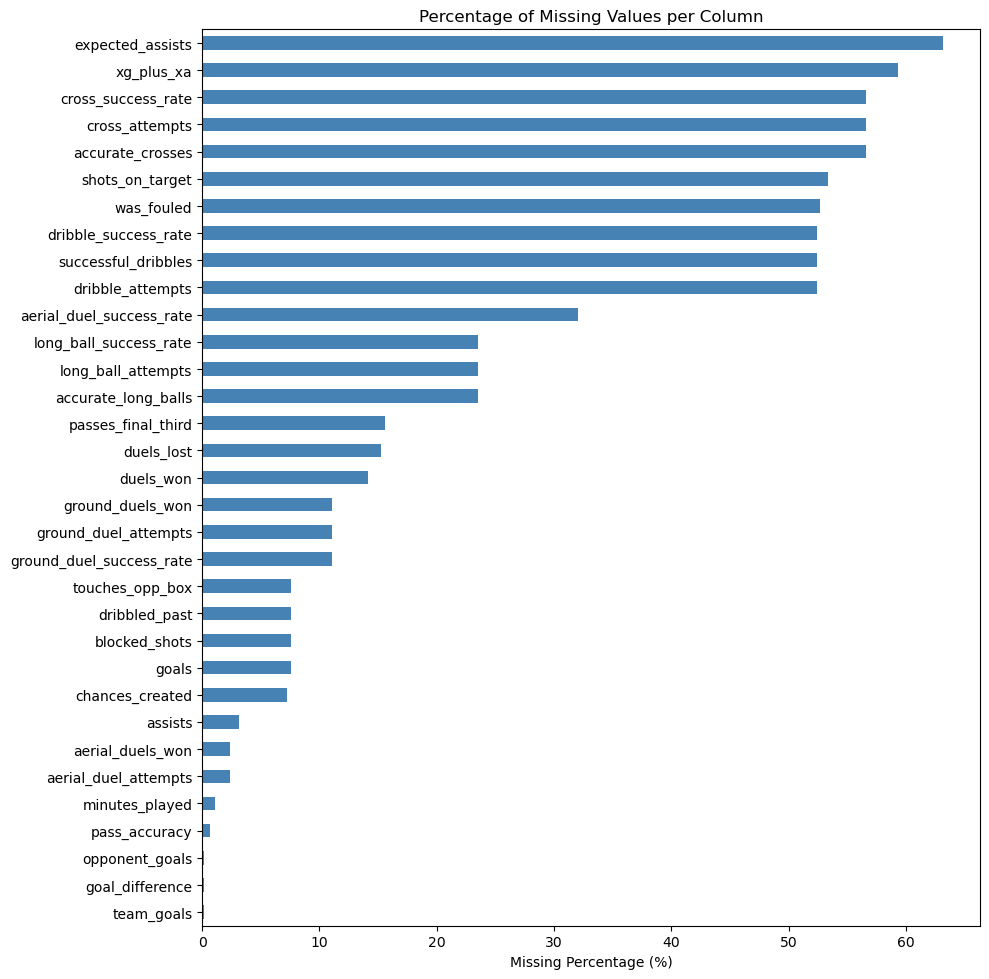

In [58]:
missing_percent = (rating_data.isnull().sum() / len(rating_data) * 100).round(2)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)


plt.figure(figsize=(10, max(6, len(missing_percent) * 0.3)))
missing_percent.plot(kind='barh', color='steelblue')
plt.xlabel('Missing Percentage (%)')
plt.title('Percentage of Missing Values per Column')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

In [59]:
cols_to_fill_with_0 =["aerial_duel_success_rate",
                      "aerial_duel_attempts",
                      "aerial_duels_won",
                      "ground_duel_success_rate",
                      "ground_duels_won",
                      "ground_duel_attempts",
                      "dribbled_past",
                      "accurate_long_balls",
                      "long_ball_attempts",
                      "long_ball_success_rate",
                      "passes_final_third",
                      "pass_accuracy",
                      "chances_created",
                      "blocked_shots",
                      "goals",
                      "shots_on_target",
                      "assists"]
rating_data[cols_to_fill_with_0] = rating_data[cols_to_fill_with_0].fillna(0)

In [60]:
conditions = [
    (rating_data['duels_lost'].isna()) & (rating_data['aerial_duel_success_rate'] == 100) & (rating_data['ground_duel_success_rate'] == 100),
    (rating_data['duels_lost'].isna()) & (rating_data['aerial_duel_success_rate'] == 0) & (rating_data['ground_duel_success_rate'] == 100),
    (rating_data['duels_lost'].isna()) & (rating_data['aerial_duel_success_rate'] == 100) & (rating_data['ground_duel_success_rate'] == 0),
    (rating_data['duels_lost'].isna()) & (rating_data['aerial_duel_success_rate'] == 0) & (rating_data['ground_duel_success_rate'] == 0)
]

choices = [
    0,
    rating_data['aerial_duels_won'],
    rating_data['ground_duels_won'],
    rating_data['aerial_duels_won'] + rating_data['ground_duels_won']
]

rating_data['Custom'] = np.select(conditions, choices, default=rating_data['duels_lost'])

In [61]:
rating_data = rating_data.drop('duels_lost', axis=1).rename(columns={'Custom': 'duels_lost'})

In [62]:
rating_data['Custom'] = np.where(
    rating_data['duels_won'].isna(),
    rating_data['aerial_duels_won'] + rating_data['ground_duels_won'],
    rating_data['duels_won']
)

In [63]:
rating_data = rating_data.drop('duels_won', axis=1).rename(columns={'Custom': 'duels_won'})

In [64]:
rating_data['Custom'] = np.where(
    rating_data['touches_opp_box'].isna(),
    np.round(rating_data['touches'] * 0.05, 0),
    rating_data['touches_opp_box']
)

In [65]:
rating_data = rating_data.drop('touches_opp_box', axis=1).rename(columns={'Custom': 'touches_opp_box'})

In [66]:
rating_data['Custom'] = np.where(
    rating_data['is_goalkeeper'] == 1,
    0,
    rating_data['touches_opp_box']
)

In [67]:
rating_data = rating_data.drop('touches_opp_box', axis=1).rename(columns={'Custom': 'touches_opp_box'})

In [68]:
rating_data["minutes_played"] = rating_data["minutes_played"].fillna(65)

In [69]:
rating_data = rating_data.dropna(subset=["team_goals", "opponent_goals", "goal_difference"])

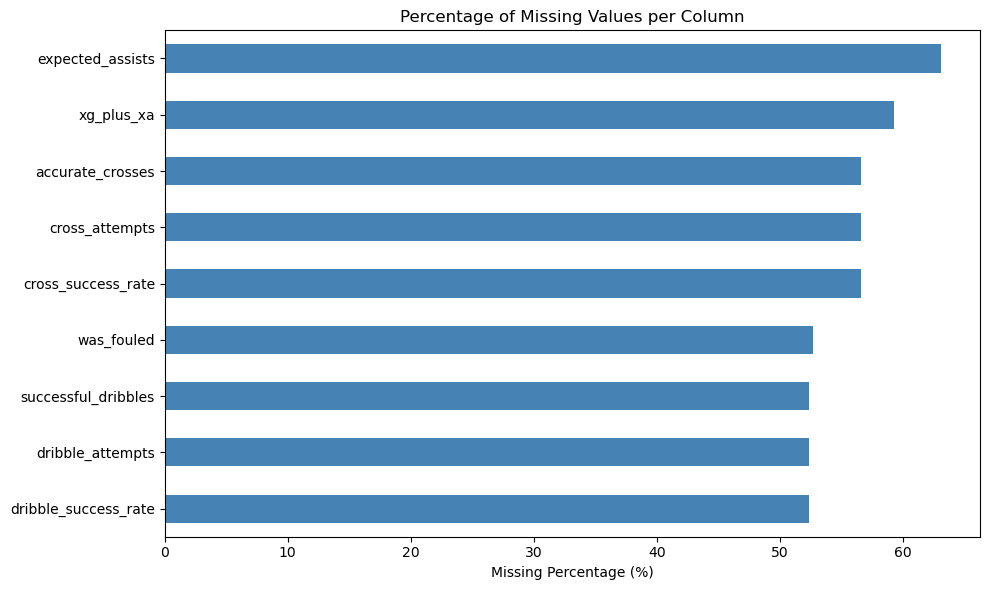

In [70]:
missing_percent = (rating_data.isnull().sum() / len(rating_data) * 100).round(2)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)


plt.figure(figsize=(10, max(6, len(missing_percent) * 0.3)))
missing_percent.plot(kind='barh', color='steelblue')
plt.xlabel('Missing Percentage (%)')
plt.title('Percentage of Missing Values per Column')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

In [71]:
#columns with more than 50 % null is not usefull 
rating_data = rating_data.drop(
    rating_data.columns[rating_data.isnull().mean() > 0.4],
    axis=1
)

In [72]:
rating_data['team_result'] = rating_data['team_result'].replace({
    'win': 2,
    'draw': 1,
    'loss': 0
})

C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_13184\2454010382.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rating_data['team_result'] = rating_data['team_result'].replace({


In [73]:
#we dont need this columns for analysis
cols_to_drop = [
    'match_id', 'player_id', 'team_id', 'league_id',
    'home_team_id', 'away_team_id',
    'player_name', 'team_name', 'league_name',
    'country_code', 'parent_league_name', 'parent_league_season',
    'match_date', 'home_team_name', 'away_team_name'
]
rating_data = rating_data.drop(cols_to_drop, axis=1)

In [74]:
rating_data.columns

Index(['home_score', 'away_score', 'is_home_team', 'team_goals',
       'opponent_goals', 'goal_difference', 'team_result', 'is_goalkeeper',
       'player_rating', 'minutes_played', 'goals', 'assists',
       'shots_on_target', 'blocked_shots', 'chances_created', 'touches',
       'accurate_passes', 'total_passes', 'pass_accuracy',
       'passes_final_third', 'accurate_long_balls', 'long_ball_attempts',
       'long_ball_success_rate', 'tackles_won', 'interceptions', 'clearances',
       'defensive_actions', 'recoveries', 'dribbled_past', 'ground_duels_won',
       'ground_duel_attempts', 'ground_duel_success_rate', 'aerial_duels_won',
       'aerial_duel_attempts', 'aerial_duel_success_rate', 'fouls_committed',
       'duels_lost', 'duels_won', 'touches_opp_box'],
      dtype='object')

Data Modeling

In [75]:
X_players_rating = rating_data.drop("player_rating",axis = 1)
X_players_rating.shape

(173334, 38)

In [76]:
y_players_rating = rating_data["player_rating"]
y_players_rating.shape

(173334,)

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X_players_rating, y_players_rating, test_size=0.2, random_state=42)

In [79]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [80]:
y_pred = model.predict(X_test)

In [ ]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R²: 0.8499464674722934
MAE: 0.1958445026764871
RMSE: 0.2935668449321533


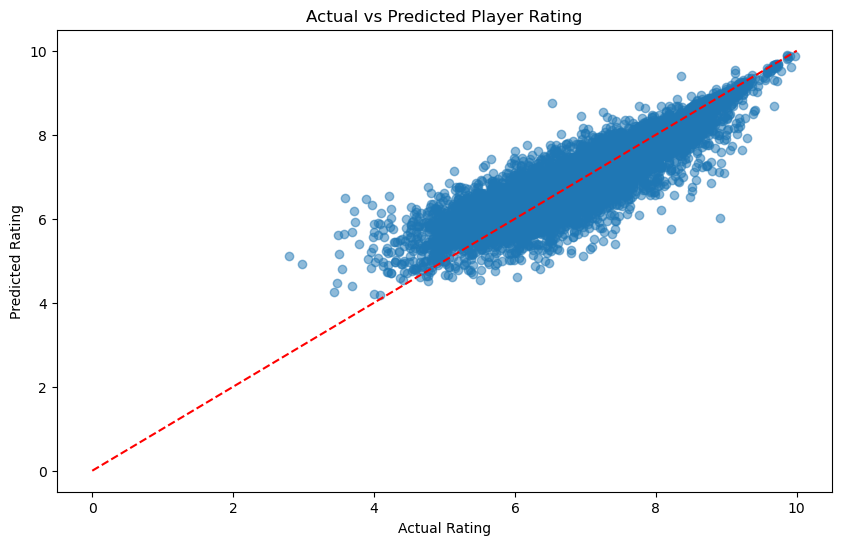

In [83]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Player Rating')
plt.plot([0, 10], [0, 10], 'r--')  
plt.show()